In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
from google.colab import files
import io

In [ ]:
uploaded = files.upload()
df = pd.read_excel(io.BytesIO(list(uploaded.values())[0]))

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()
print("Dataset caricato.")
print(df.shape)

Saving DATA SET DEFINITIVO.xlsx to DATA SET DEFINITIVO.xlsx
Dataset caricato.
(160, 9)


In [ ]:
df['outcome'] = (df['construction'] == 'AA').astype(int)
df = df.rename(columns={
    'information Status': 'information_status',
    'Topic persistence': 'topic_persistence',
    'Discourse Hierarchy': 'discourse_hierarchy',
    'Position ': 'position'
})
print("Distribuzione outcome:")
print(df['outcome'].value_counts())

Distribuzione outcome:
outcome
1    89
0    71
Name: count, dtype: int64


In [ ]:
formula = 'outcome ~ C(position) + C(information_status) + C(topic_persistence) + C(discourse_hierarchy) + C(Agentivity)'
model = smf.logit(formula, data=df).fit_regularized(alpha=0.1, method='l1')
print(model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.05253449610046196
            Iterations: 121
            Function evaluations: 122
            Gradient evaluations: 121
                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                  160
Model:                          Logit   Df Residuals:                      152
Method:                           MLE   Df Model:                            7
Date:                Mon, 01 Jun 2026   Pseudo R-squ.:                  0.9614
Time:                        15:30:18   Log-Likelihood:                -4.2370
converged:                       True   LL-Null:                       -109.89
Covariance Type:            nonrobust   LLR p-value:                 4.617e-42
                                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

In [ ]:
odds_ratios = pd.DataFrame({
    'Coefficiente': model.params,
    'Odds Ratio': np.exp(model.params),
}).round(4)
print("\nODDS RATIO:")
print(odds_ratios)

df['predicted'] = (model.predict() > 0.5).astype(int)
accuracy = (df['predicted'] == df['outcome']).mean()
print(f"Accuratezza predittiva: {accuracy:.4f} ({accuracy*100:.1f}%)")


ODDS RATIO:
                                       Coefficiente  Odds Ratio
Intercept                                   -3.5562      0.0285
C(position)[T.1]                            -7.9619      0.0003
C(information_status)[T.new]                 7.2067   1348.4475
C(information_status)[T.recap]               5.1678    175.5250
C(topic_persistence)[T.discontinuous]        1.7996      6.0472
C(topic_persistence)[T.setting]              4.5842     97.9267
C(discourse_hierarchy)[T.B]                 -5.1621      0.0057
C(Agentivity)[T.D]                           6.2462    516.0589
Accuratezza predittiva: 0.9938 (99.4%)


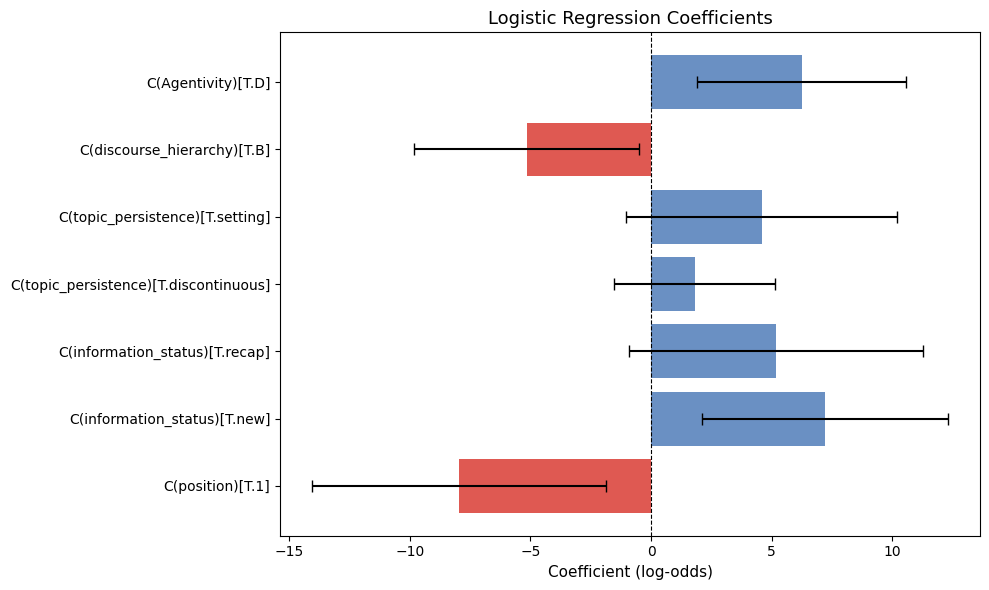

In [ ]:
import matplotlib.pyplot as plt

coefs = model.params.drop('Intercept')
conf = model.conf_int().drop('Intercept')

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(coefs))

ax.barh(y_pos, coefs.values, xerr=[coefs.values - conf[0].values, conf[1].values - coefs.values],
        align='center', color=['#d73027' if c < 0 else '#4575b4' for c in coefs.values],
        alpha=0.8, capsize=4)

ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(coefs.index, fontsize=10)
ax.set_xlabel('Coefficient (log-odds)', fontsize=11)
ax.set_title('Logistic Regression Coefficients', fontsize=13)
plt.tight_layout()
plt.savefig('coefficients.png', dpi=300)
plt.show()

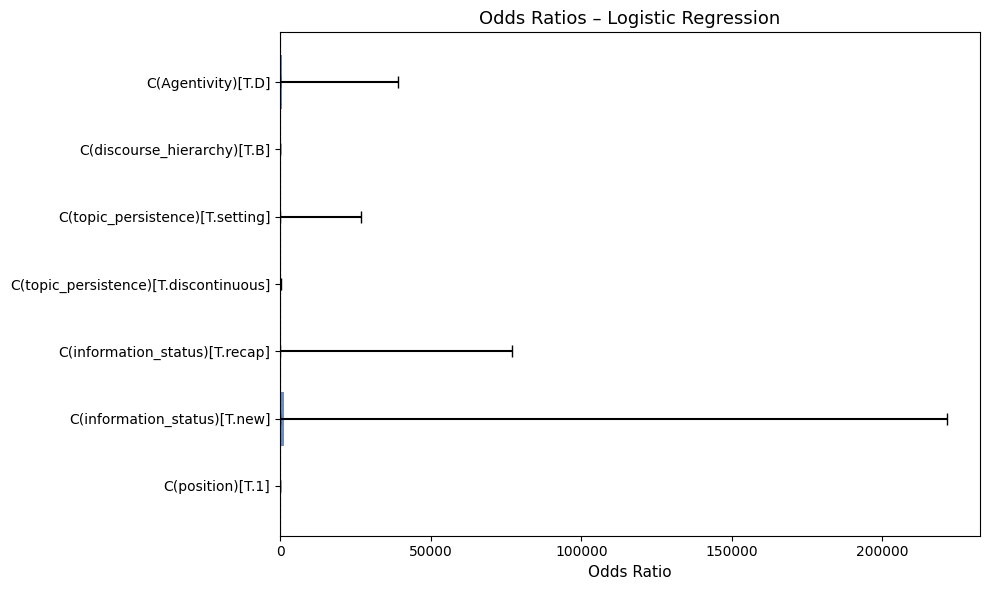

In [ ]:
or_vals = np.exp(model.params.drop('Intercept'))
or_conf = np.exp(model.conf_int().drop('Intercept'))

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(or_vals))

ax.barh(y_pos, or_vals.values, xerr=[or_vals.values - or_conf[0].values, or_conf[1].values - or_vals.values],
        align='center', color=['#d73027' if v < 1 else '#4575b4' for v in or_vals.values],
        alpha=0.8, capsize=4)

ax.axvline(x=1, color='black', linestyle='--', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(or_vals.index, fontsize=10)
ax.set_xlabel('Odds Ratio', fontsize=11)
ax.set_title('Odds Ratios – Logistic Regression', fontsize=13)
plt.tight_layout()
plt.savefig('odds_ratios.png', dpi=300)
plt.show()

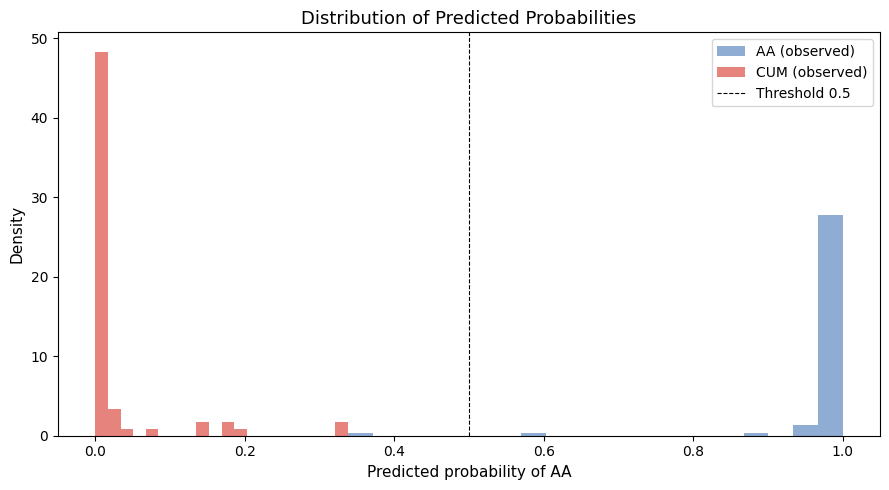

In [ ]:
df['prob_AA'] = model.predict()

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df[df['outcome'] == 1]['prob_AA'], bins=20, alpha=0.6,
        color='#4575b4', label='AA (observed)', density=True)
ax.hist(df[df['outcome'] == 0]['prob_AA'], bins=20, alpha=0.6,
        color='#d73027', label='CUM (observed)', density=True)

ax.axvline(x=0.5, color='black', linestyle='--', linewidth=0.8, label='Threshold 0.5')
ax.set_xlabel('Predicted probability of AA', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Distribution of Predicted Probabilities', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('predicted_probabilities.png', dpi=300)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Prepara le variabili — solo le 5 funzionali, senza Author e Work
features = ['position', 'information_status', 'topic_persistence', 'discourse_hierarchy', 'Agentivity']

df_rf = df[features + ['outcome']].dropna()

# Encode categoriche
df_encoded = df_rf.copy()
for col in features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded[features]
y = df_encoded['outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
print(f"Training set: {len(X_train)} | Test set: {len(X_test)}")

Training set: 128 | Test set: 32


In [ ]:
rf = RandomForestClassifier(n_estimators=1000, max_features=3, random_state=123, oob_score=True)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
oob = rf.oob_score_

print(f"Test Accuracy:  {acc:.4f} ({acc*100:.1f}%)")
print(f"OOB Score:      {oob:.4f} ({oob*100:.1f}%)")

Test Accuracy:  0.9375 (93.8%)
OOB Score:      0.9609 (96.1%)


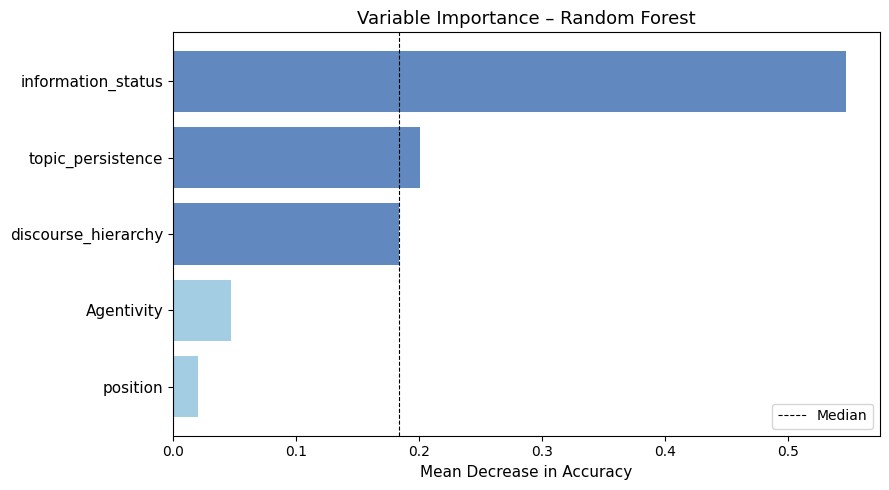

In [ ]:
importances = rf.feature_importances_
indices = np.argsort(importances)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(indices)), importances[indices],
        color=['#4575b4' if importances[i] >= np.median(importances) else '#92c5de' for i in indices],
        alpha=0.85)
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([features[i] for i in indices], fontsize=11)
ax.set_xlabel('Mean Decrease in Accuracy', fontsize=11)
ax.set_title('Variable Importance – Random Forest', fontsize=13)
ax.axvline(x=np.median(importances), color='black', linestyle='--', linewidth=0.8, label='Median')
ax.legend()
plt.tight_layout()
plt.savefig('rf_importance.png', dpi=300)
plt.show()

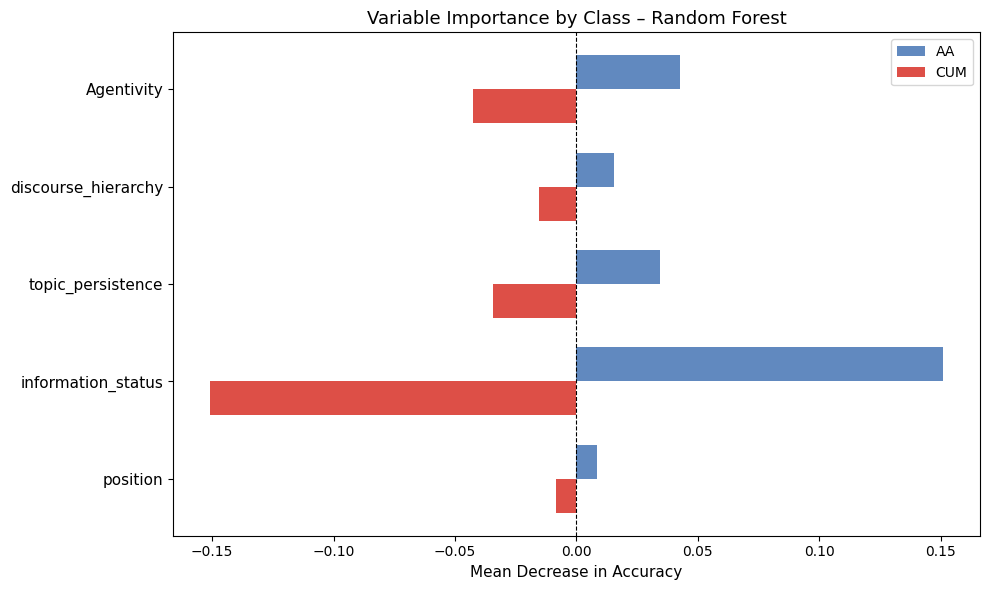

In [ ]:
from sklearn.inspection import permutation_importance

# Permutation importance separata per classe AA e CUM
result_aa = permutation_importance(rf, X_test, (y_test == 1).astype(int), n_repeats=30, random_state=123)
result_cum = permutation_importance(rf, X_test, (y_test == 0).astype(int), n_repeats=30, random_state=123)

imp_aa = result_aa.importances_mean
imp_cum = result_cum.importances_mean

x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.barh(x + width/2, imp_aa, width, label='AA', color='#4575b4', alpha=0.85)
bars2 = ax.barh(x - width/2, imp_cum, width, label='CUM', color='#d73027', alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(features, fontsize=11)
ax.set_xlabel('Mean Decrease in Accuracy', fontsize=11)
ax.set_title('Variable Importance by Class – Random Forest', fontsize=13)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.savefig('rf_importance_by_class.png', dpi=300)
plt.show()

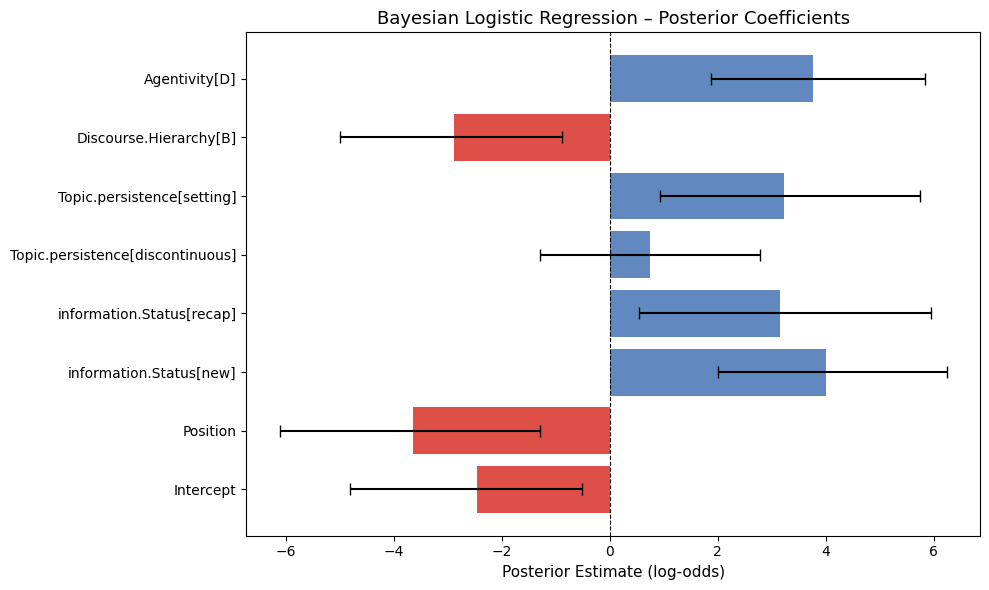

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Valori dal PDF del prof
params = [
    'Intercept', 'Position', 'information.Status[new]',
    'information.Status[recap]', 'Topic.persistence[discontinuous]',
    'Topic.persistence[setting]', 'Discourse.Hierarchy[B]', 'Agentivity[D]'
]
estimates = [-2.46, -3.64, 4.01, 3.16, 0.75, 3.23, -2.88, 3.76]
lower     = [-4.80, -6.11,  2.00, 0.55, -1.28, 0.94, -4.99,  1.87]
upper     = [-0.51, -1.29,  6.24, 5.95,  2.79, 5.75, -0.89,  5.83]

errors_low  = [e - l for e, l in zip(estimates, lower)]
errors_high = [u - e for e, u in zip(estimates, upper)]
colors = ['#d73027' if e < 0 else '#4575b4' for e in estimates]

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(params))

ax.barh(y_pos, estimates,
        xerr=[errors_low, errors_high],
        align='center', color=colors, alpha=0.85, capsize=4)

ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(params, fontsize=10)
ax.set_xlabel('Posterior Estimate (log-odds)', fontsize=11)
ax.set_title('Bayesian Logistic Regression – Posterior Coefficients', fontsize=13)
plt.tight_layout()
plt.savefig('bayesian_coefficients.png', dpi=300)
plt.show()

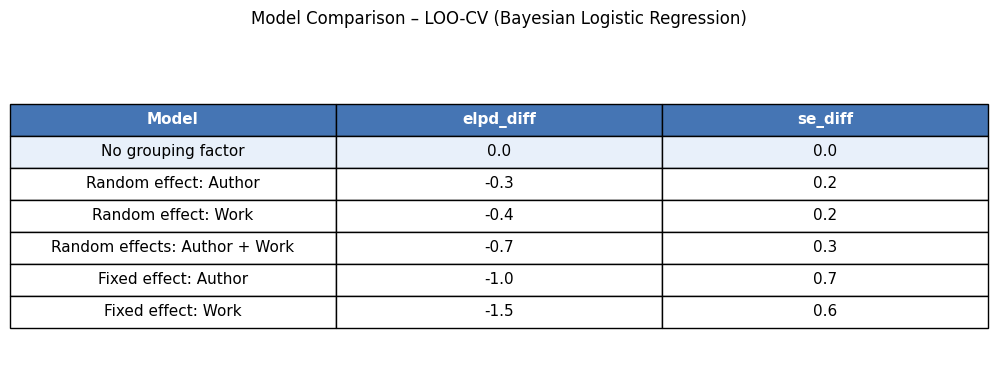

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

loo_data = {
    'Model': [
        'No grouping factor',
        'Random effect: Author',
        'Random effect: Work',
        'Random effects: Author + Work',
        'Fixed effect: Author',
        'Fixed effect: Work'
    ],
    'elpd_diff': [0.0, -0.3, -0.4, -0.7, -1.0, -1.5],
    'se_diff':   [0.0,  0.2,  0.2,  0.3,  0.7,  0.6]
}

df_loo = pd.DataFrame(loo_data)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=df_loo.values,
    colLabels=df_loo.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Intestazione in blu
for j in range(len(df_loo.columns)):
    table[0, j].set_facecolor('#4575b4')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Prima riga (modello migliore) evidenziata
for j in range(len(df_loo.columns)):
    table[1, j].set_facecolor('#e8f0fa')

ax.set_title('Model Comparison – LOO-CV (Bayesian Logistic Regression)',
             fontsize=12, pad=20)

plt.tight_layout()
plt.savefig('loo_comparison.png', dpi=300)
plt.show()